# Fase 2 - Análisis Univariado: Tarifas, Distancias y Propinas

**Pregunta de negocio:** ¿Cómo se distribuyen tarifas, distancias y propinas en los viajes de taxi amarillo de NYC?

## Objetivos de este notebook

1. Cargar una muestra limpia de ~100K viajes desde BigQuery con columnas derivadas
2. Explorar las distribuciones de `fare_amount`, `trip_distance` y `tip_amount`
3. Identificar valores atípicos (outliers) usando métodos IQR y z-score
4. Comparar distribuciones por tipo de pago y zona
5. Aplicar transformaciones logarítmicas para distribuciones sesgadas

## ¿Por qué importa el análisis univariado?

Antes de construir modelos o buscar relaciones entre variables, debemos entender cada variable
por separado. Esto nos permite:
- Detectar errores en los datos
- Identificar outliers que pueden distorsionar los análisis
- Elegir las transformaciones y métodos estadísticos adecuados

## 1. Configuración e importaciones

In [1]:
# Conexión a BigQuery
import sys
sys.path.insert(0, '../../../src')
from bigquery.bq_helper import BigQueryHelper
bq = BigQueryHelper()

✓ Conectado a BigQuery - Proyecto: gen-lang-client-0180273702
✓ Cache en: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/data/nyc_taxi/cache


In [2]:
# Librerías de análisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Para mostrar todas las columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## 2. Carga de datos desde BigQuery

Extraemos una muestra aleatoria de ~100,000 viajes con filtros básicos de calidad.
Incluimos columnas derivadas calculadas directamente en SQL para mayor eficiencia:

- **`duration_min`**: duración del viaje en minutos
- **`speed_mph`**: velocidad promedio en millas por hora
- **`tip_pct`**: propina como porcentaje de la tarifa

In [3]:
query = """
SELECT
    pickup_datetime,
    dropoff_datetime,
    passenger_count,
    trip_distance,
    pickup_location_id,
    dropoff_location_id,
    payment_type,
    fare_amount,
    tip_amount,
    tolls_amount,
    total_amount,
    rate_code,
    -- Columnas derivadas
    TIMESTAMP_DIFF(dropoff_datetime, pickup_datetime, SECOND) / 60.0 AS duration_min,
    CASE
        WHEN TIMESTAMP_DIFF(dropoff_datetime, pickup_datetime, SECOND) > 0
             AND trip_distance > 0
        THEN trip_distance / (TIMESTAMP_DIFF(dropoff_datetime, pickup_datetime, SECOND) / 3600.0)
        ELSE NULL
    END AS speed_mph,
    CASE
        WHEN fare_amount > 0
        THEN (tip_amount / fare_amount) * 100
        ELSE NULL
    END AS tip_pct,
    -- Zona de recogida basada en TLC Taxi Zone ID
    CASE
        WHEN pickup_location_id = '132' THEN 'JFK'
        WHEN pickup_location_id = '138' THEN 'LaGuardia'
        WHEN pickup_location_id IN ('4','12','13','24','41','42','43','45','48','50','68','74','75','79','87','88','90','100','107','113','114','116','125','127','128','137','140','141','142','143','144','148','151','152','153','158','161','162','163','164','166','170','186','194','202','209','211','224','229','230','231','232','233','234','236','237','238','239','243','244','246','249','261','262','263') THEN 'Manhattan'
        WHEN pickup_location_id IN ('11','14','17','21','22','25','26','29','33','34','35','36','37','39','40','49','52','54','55','61','62','63','65','66','67','69','71','72','76','77','80','85','89','91','97','106','108','111','112','123','133','149','150','154','155','165','177','178','181','188','189','190','195','210','217','222','225','227','228','255','256','257') THEN 'Brooklyn'
        ELSE 'Queens/Otro'
    END AS zona
FROM
    `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2015`
WHERE
    fare_amount > 0
    AND fare_amount < 500
    AND trip_distance > 0
    AND trip_distance < 100
    AND passenger_count > 0
    AND pickup_location_id IS NOT NULL
    AND TIMESTAMP_DIFF(dropoff_datetime, pickup_datetime, SECOND) > 60
    AND TIMESTAMP_DIFF(dropoff_datetime, pickup_datetime, SECOND) < 7200
ORDER BY RAND()
LIMIT 100000
"""

df = bq.query_to_df(query)
print(f"Registros cargados: {len(df):,}")
df.head()

📊 Estimación: 16.263 GB → $0.0993 USD
⏳ Ejecutando query...
✓ Completado: 100,000 filas en 15.8s
💾 Cache guardado: 8d881028e54f.parquet (3.5 MB)
Registros cargados: 100,000


,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,pickup_location_id,dropoff_location_id,payment_type,fare_amount,tip_amount,tolls_amount,total_amount,rate_code,duration_min,speed_mph,tip_pct,zona
0,2015-09-24 05:19:16+00:00,2015-09-24 05:37:12+00:00,1,9.66,238,213,2,28.50,0.00,0.00,29.80,1,17.93,32.32,0.00,Manhattan
1,2015-05-28 14:54:10+00:00,2015-05-28 15:00:17+00:00,1,0.65,234,170,1,5.50,1.26,0.00,7.56,1,6.12,6.38,22.91,Manhattan
2,2015-06-19 20:05:37+00:00,2015-06-19 20:11:05+00:00,2,1.40,237,236,1,6.50,1.55,0.00,9.35,1,5.47,15.37,23.85,Manhattan
3,2015-11-30 21:47:46+00:00,2015-11-30 21:59:40+00:00,1,3.90,112,148,1,14.00,3.05,0.00,18.35,1,11.90,19.66,21.79,Brooklyn
4,2015-01-15 17:27:17+00:00,2015-01-15 17:39:25+00:00,1,1.73,141,142,2,9.50,0.00,0.00,11.30,1,12.13,8.55,0.00,Manhattan


In [4]:
# Verificación rápida de tipos y valores nulos
print("Tipos de datos:")
print(df.dtypes)
print(f"\nValores nulos por columna:")
print(df.isnull().sum())

Tipos de datos:
pickup_datetime        datetime64[us, UTC]
dropoff_datetime       datetime64[us, UTC]
passenger_count                      Int64
trip_distance                      float64
pickup_location_id                  object
dropoff_location_id                 object
payment_type                        object
fare_amount                        float64
tip_amount                         float64
tolls_amount                       float64
total_amount                       float64
rate_code                           object
duration_min                       float64
speed_mph                          float64
tip_pct                            float64
zona                                object
dtype: object

Valores nulos por columna:
pickup_datetime        0
dropoff_datetime       0
passenger_count        0
trip_distance          0
pickup_location_id     0
dropoff_location_id    0
payment_type           0
fare_amount            0
tip_amount             0
tolls_amount           0
tota

## 3. Histogramas de variables clave

Los histogramas nos muestran la **forma de la distribución**: si es simétrica, sesgada,
unimodal o multimodal. Esto es fundamental para elegir las estadísticas descriptivas
correctas (media vs. mediana) y los tests estadísticos apropiados.

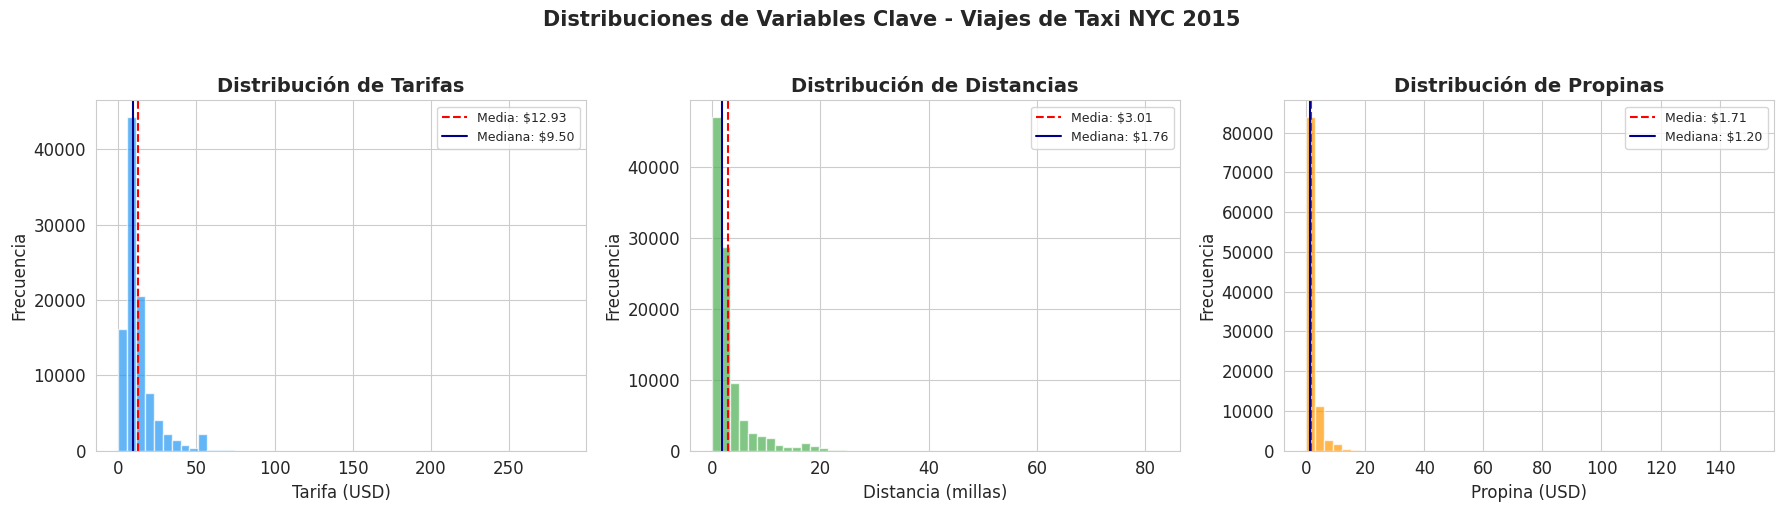


📌 Observación: Las tres distribuciones presentan sesgo positivo (cola derecha larga).
Esto es típico en datos monetarios y de distancias.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

variables = {
    'fare_amount': {'title': 'Distribución de Tarifas', 'xlabel': 'Tarifa (USD)', 'color': '#2196F3'},
    'trip_distance': {'title': 'Distribución de Distancias', 'xlabel': 'Distancia (millas)', 'color': '#4CAF50'},
    'tip_amount': {'title': 'Distribución de Propinas', 'xlabel': 'Propina (USD)', 'color': '#FF9800'}
}

for ax, (col, props) in zip(axes, variables.items()):
    ax.hist(df[col], bins=50, color=props['color'], alpha=0.7, edgecolor='white')
    ax.set_title(props['title'], fontweight='bold')
    ax.set_xlabel(props['xlabel'])
    ax.set_ylabel('Frecuencia')
    
    # Líneas de referencia: media y mediana
    media = df[col].mean()
    mediana = df[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5, label=f'Media: ${media:.2f}')
    ax.axvline(mediana, color='darkblue', linestyle='-', linewidth=1.5, label=f'Mediana: ${mediana:.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Distribuciones de Variables Clave - Viajes de Taxi NYC 2015', 
             fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print("\n📌 Observación: Las tres distribuciones presentan sesgo positivo (cola derecha larga).")
print("Esto es típico en datos monetarios y de distancias.")

## 4. KDE (Kernel Density Estimation) sobre histogramas

La estimación de densidad por kernel (KDE) es una versión suavizada del histograma.
Nos ayuda a visualizar la forma de la distribución sin depender del número de bins.

**Ventaja sobre el histograma:** el KDE produce una curva continua, lo que facilita
comparar distribuciones y detectar multimodalidad.

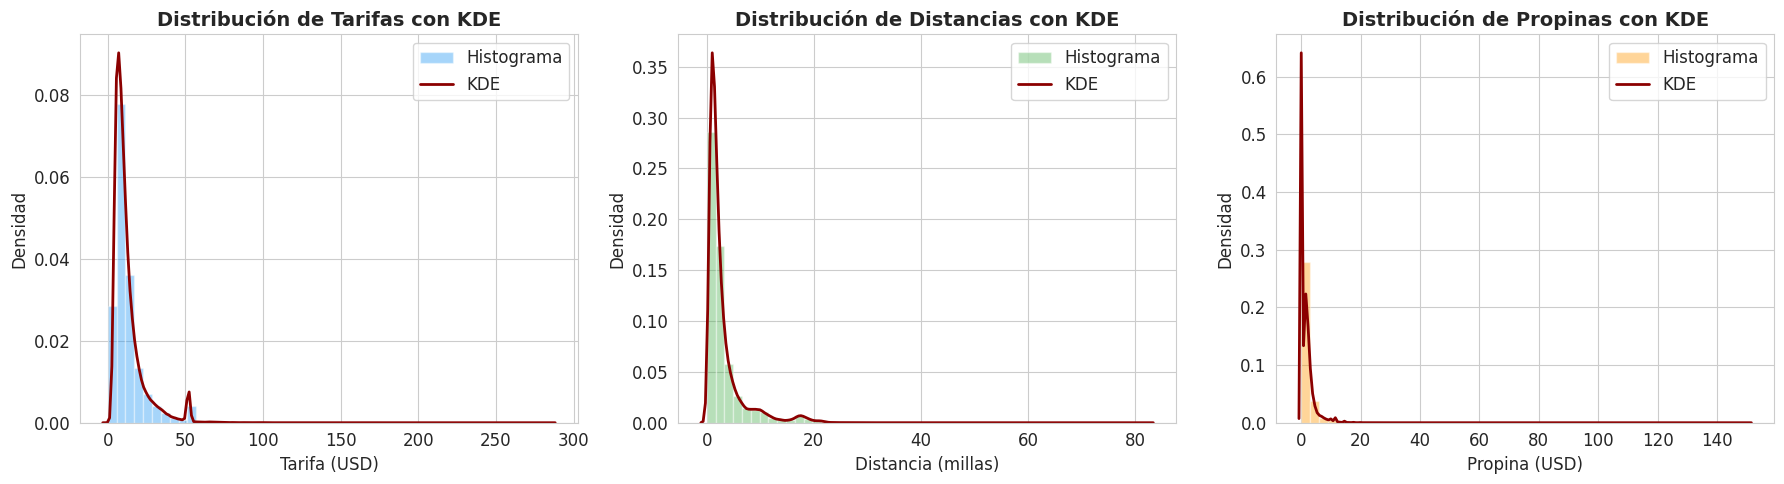


Estadísticas de asimetría (skewness) y curtosis:
--------------------------------------------------
fare_amount          | Asimetría: +3.23 | Curtosis: 22.67
trip_distance        | Asimetría: +3.12 | Curtosis: 13.95
tip_amount           | Asimetría: +5.73 | Curtosis: 173.53

📌 Interpretación:
   - Asimetría > 0: distribución sesgada a la derecha
   - Curtosis > 3: colas más pesadas que una distribución normal (leptocúrtica)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, props) in zip(axes, variables.items()):
    # Histograma normalizado (density=True) para que sea compatible con el KDE
    ax.hist(df[col], bins=50, density=True, color=props['color'], alpha=0.4, 
            edgecolor='white', label='Histograma')
    
    # KDE superpuesto
    sns.kdeplot(data=df[col], ax=ax, color='darkred', linewidth=2, label='KDE')
    
    ax.set_title(props['title'] + ' con KDE', fontweight='bold')
    ax.set_xlabel(props['xlabel'])
    ax.set_ylabel('Densidad')
    ax.legend()

plt.tight_layout()
plt.show()

# Estadísticas de forma
print("\nEstadísticas de asimetría (skewness) y curtosis:")
print("-" * 50)
for col in variables.keys():
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    print(f"{col:20s} | Asimetría: {skew:+.2f} | Curtosis: {kurt:.2f}")

print("\n📌 Interpretación:")
print("   - Asimetría > 0: distribución sesgada a la derecha")
print("   - Curtosis > 3: colas más pesadas que una distribución normal (leptocúrtica)")

## 5. Box plots: tarifa por tipo de pago

Los box plots (diagramas de caja) nos permiten comparar distribuciones entre grupos.
Cada caja muestra:
- **Línea central:** mediana (percentil 50)
- **Caja:** rango intercuartílico (IQR, percentiles 25-75)
- **Bigotes:** 1.5 × IQR desde los bordes de la caja
- **Puntos:** outliers fuera de los bigotes

/tmp/ipykernel_21629/2876035042.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


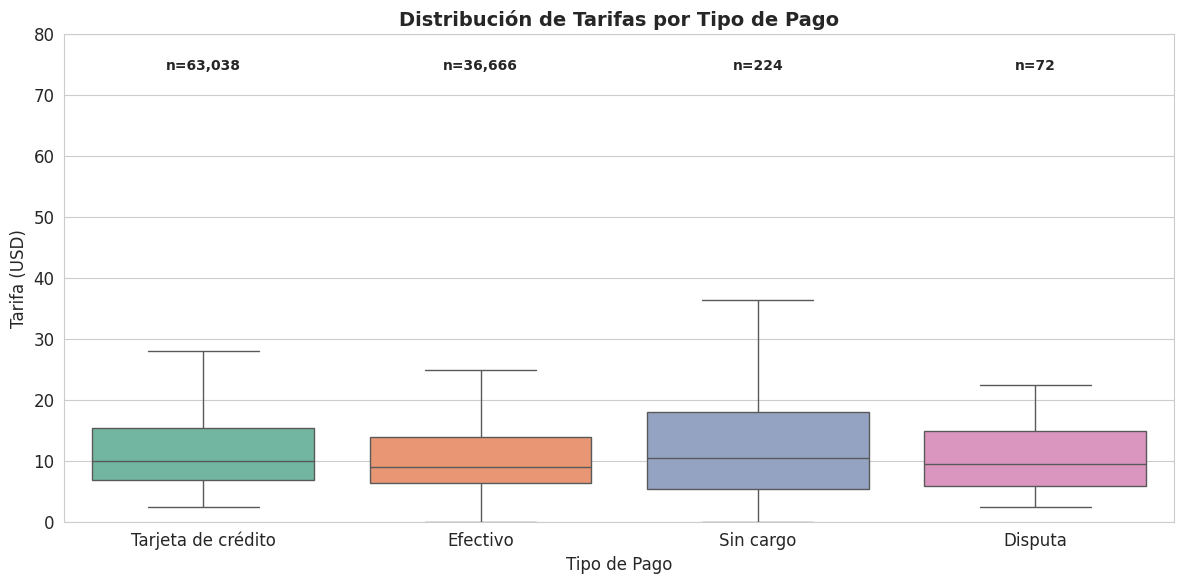


Estadísticas de tarifa por tipo de pago:
                      count  mean   std  min  25%   50%   75%    max
payment_label                                                       
Disputa               72.00 15.40 18.02 2.50 6.00  9.50 15.00 104.00
Efectivo           36666.00 12.08 10.00 0.01 6.50  9.00 14.00 200.00
Sin cargo            224.00 15.35 14.65 0.01 5.50 10.50 18.00  76.00
Tarjeta de crédito 63038.00 13.41 10.87 2.50 7.00 10.00 15.50 285.00


In [7]:
# Mapeo de tipos de pago
payment_labels = {
    '1': 'Tarjeta de crédito',
    '2': 'Efectivo',
    '3': 'Sin cargo',
    '4': 'Disputa'
}

df['payment_label'] = df['payment_type'].astype(str).map(payment_labels)
# Filtrar solo tipos de pago conocidos
df_payments = df[df['payment_label'].notna()].copy()

fig, ax = plt.subplots(figsize=(12, 6))

order = ['Tarjeta de crédito', 'Efectivo', 'Sin cargo', 'Disputa']
existing_order = [o for o in order if o in df_payments['payment_label'].unique()]

sns.boxplot(
    data=df_payments, 
    x='payment_label', 
    y='fare_amount',
    order=existing_order,
    palette='Set2',
    showfliers=False,  # Ocultamos outliers extremos para mejor visualización
    ax=ax
)

ax.set_title('Distribución de Tarifas por Tipo de Pago', fontweight='bold')
ax.set_xlabel('Tipo de Pago')
ax.set_ylabel('Tarifa (USD)')
ax.set_ylim(0, 80)

# Agregar conteo de cada categoría
counts = df_payments['payment_label'].value_counts()
for i, label in enumerate(existing_order):
    if label in counts.index:
        ax.text(i, ax.get_ylim()[1] * 0.95, f'n={counts[label]:,}', 
                ha='center', va='top', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Estadísticas por grupo
print("\nEstadísticas de tarifa por tipo de pago:")
print(df_payments.groupby('payment_label')['fare_amount'].describe().round(2))

## 6. Detección de outliers: Métodos IQR y Z-score

### Método IQR (Rango Intercuartílico)
Un valor es outlier si cae fuera de:
- **Límite inferior:** Q1 - 1.5 × IQR
- **Límite superior:** Q3 + 1.5 × IQR

### Método Z-score
Mide cuántas desviaciones estándar se aleja un valor de la media.
Generalmente, |z| > 3 se considera outlier.

**Importante:** El método IQR es más robusto ante distribuciones sesgadas,
mientras que el z-score asume normalidad.

In [8]:
def detect_outliers_iqr(series, multiplier=1.5):
    """Detecta outliers usando el método IQR."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    outliers = (series < lower) | (series > upper)
    return outliers, lower, upper

def detect_outliers_zscore(series, threshold=3):
    """Detecta outliers usando z-score."""
    z_scores = np.abs(stats.zscore(series.dropna()))
    outlier_mask = pd.Series(False, index=series.index)
    outlier_mask[series.dropna().index] = z_scores > threshold
    return outlier_mask

# Aplicar ambos métodos a fare_amount
print("=" * 65)
print("DETECCIÓN DE OUTLIERS EN VARIABLES CLAVE")
print("=" * 65)

results = []
for col in ['fare_amount', 'trip_distance', 'tip_amount']:
    iqr_mask, lower, upper = detect_outliers_iqr(df[col])
    zscore_mask = detect_outliers_zscore(df[col])
    
    n_iqr = iqr_mask.sum()
    n_zscore = zscore_mask.sum()
    
    results.append({
        'Variable': col,
        'IQR_lower': lower,
        'IQR_upper': upper,
        'Outliers_IQR': n_iqr,
        'Pct_IQR': n_iqr / len(df) * 100,
        'Outliers_Zscore': n_zscore,
        'Pct_Zscore': n_zscore / len(df) * 100
    })
    
    print(f"\n--- {col} ---")
    print(f"  Método IQR: límites [{lower:.2f}, {upper:.2f}]")
    print(f"    Outliers: {n_iqr:,} ({n_iqr/len(df)*100:.1f}%)")
    print(f"  Método Z-score (|z| > 3):")
    print(f"    Outliers: {n_zscore:,} ({n_zscore/len(df)*100:.1f}%)")

outlier_summary = pd.DataFrame(results)
print("\n\nResumen comparativo:")
outlier_summary

DETECCIÓN DE OUTLIERS EN VARIABLES CLAVE

--- fare_amount ---
  Método IQR: límites [-6.25, 27.75]
    Outliers: 7,925 (7.9%)
  Método Z-score (|z| > 3):
    Outliers: 3,085 (3.1%)

--- trip_distance ---
  Método IQR: límites [-2.29, 6.55]
    Outliers: 10,446 (10.4%)
  Método Z-score (|z| > 3):
    Outliers: 3,040 (3.0%)

--- tip_amount ---
  Método IQR: límites [-3.51, 5.85]
    Outliers: 5,157 (5.2%)
  Método Z-score (|z| > 3):
    Outliers: 2,275 (2.3%)


Resumen comparativo:


,Variable,IQR_lower,IQR_upper,Outliers_IQR,Pct_IQR,Outliers_Zscore,Pct_Zscore
0,fare_amount,-6.25,27.75,7925,7.92,3085,3.08
1,trip_distance,-2.29,6.55,10446,10.45,3040,3.04
2,tip_amount,-3.51,5.85,5157,5.16,2275,2.27


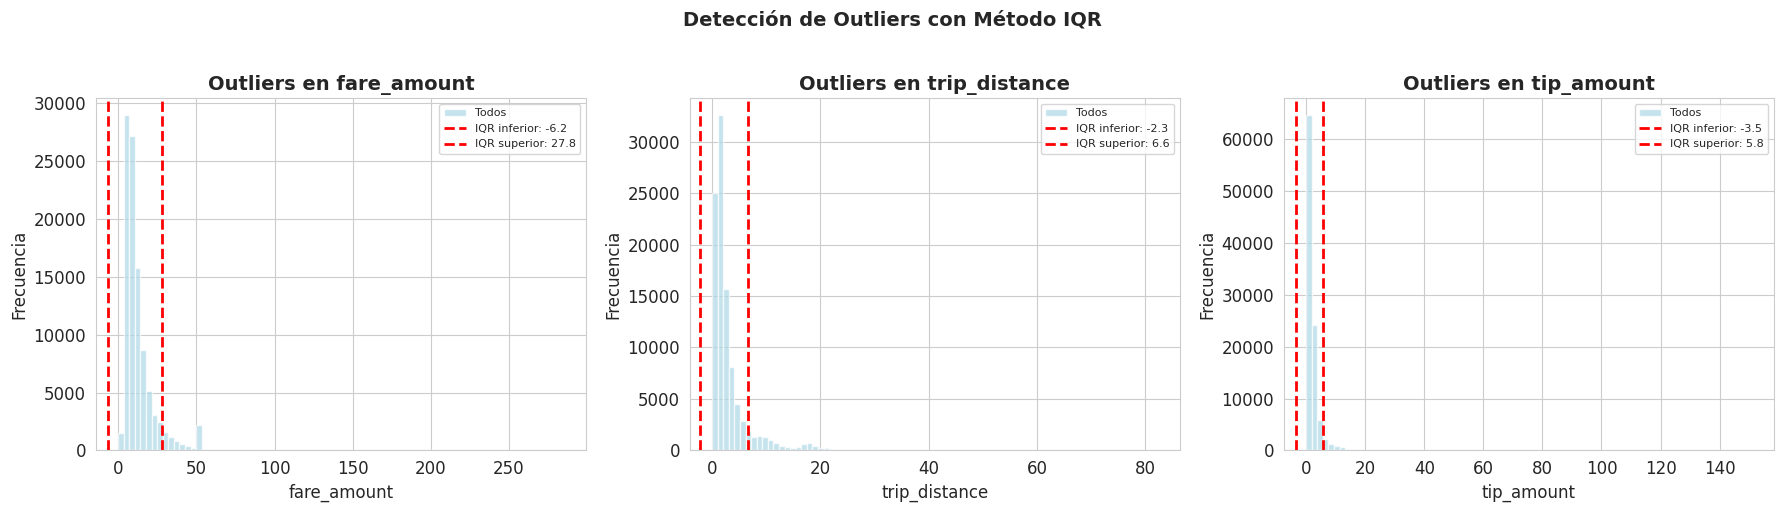

In [9]:
# Visualización: distribución con límites de outliers marcados
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['fare_amount', 'trip_distance', 'tip_amount']):
    _, lower, upper = detect_outliers_iqr(df[col])
    
    # Histograma solo de datos dentro del rango
    data_clean = df[col][(df[col] >= lower) & (df[col] <= upper)]
    data_outlier = df[col][(df[col] < lower) | (df[col] > upper)]
    
    ax.hist(df[col], bins=80, color='lightblue', alpha=0.7, edgecolor='white', label='Todos')
    ax.axvline(lower, color='red', linestyle='--', linewidth=2, label=f'IQR inferior: {lower:.1f}')
    ax.axvline(upper, color='red', linestyle='--', linewidth=2, label=f'IQR superior: {upper:.1f}')
    
    ax.set_title(f'Outliers en {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.suptitle('Detección de Outliers con Método IQR', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Violin plots: tarifa por zona de recogida

Los violin plots combinan un box plot con un KDE simétrico, mostrando tanto
las estadísticas resumidas como la forma completa de la distribución.

Utilizamos las zonas TLC (Taxi and Limousine Commission) para clasificar
la ubicación de recogida:
- **JFK:** Aeropuerto JFK (zona 132)
- **LaGuardia:** Aeropuerto LaGuardia (zona 138)
- **Manhattan:** Zonas del borough de Manhattan
- **Brooklyn:** Zonas del borough de Brooklyn
- **Queens/Otro:** Resto de zonas

/tmp/ipykernel_21629/3727821577.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


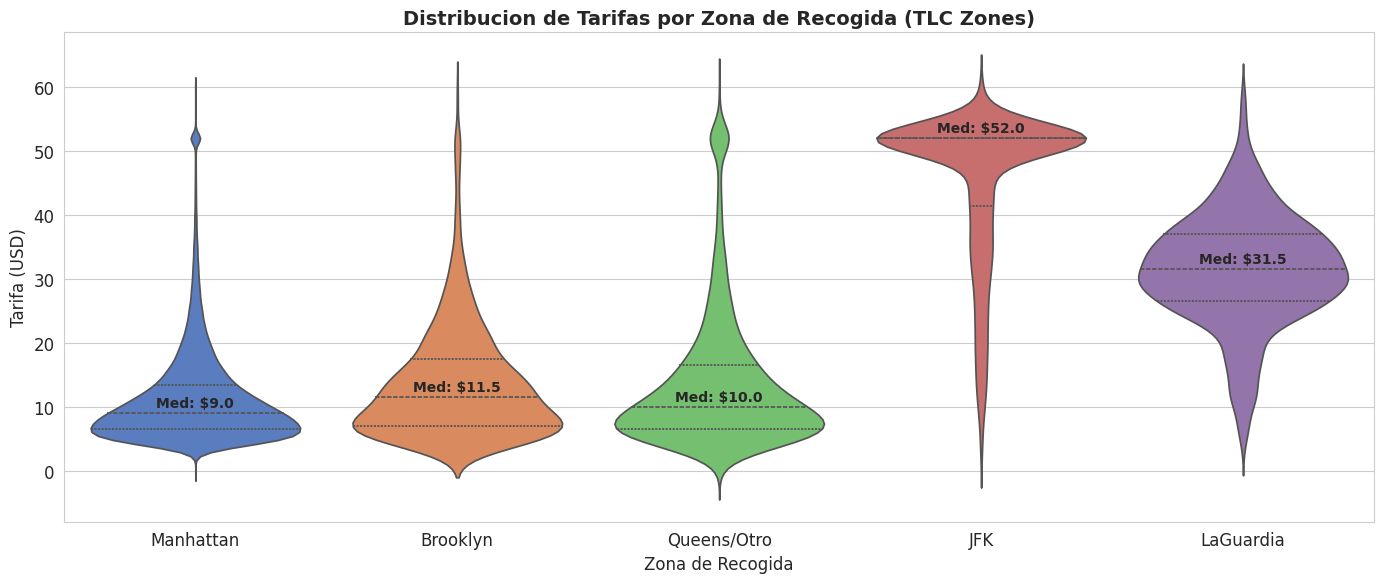


Estadisticas por zona:
             count  mean  median   std
zona                                  
Brooklyn      1806 13.69   11.50  8.99
JFK           2061 45.22   52.00 11.76
LaGuardia     2511 31.39   31.50  8.84
Manhattan    90654 11.40    9.00  7.66
Queens/Otro   2646 13.82   10.00 10.85


In [10]:
# La columna 'zona' ya viene calculada desde la consulta SQL
# Filtrar tarifas razonables para visualización
df_zone = df[(df['zona'].notna()) & (df['fare_amount'] <= 60)].copy()

# Orden de las zonas para el gráfico
zone_order = ['Manhattan', 'Brooklyn', 'Queens/Otro', 'JFK', 'LaGuardia']
existing_zones = [z for z in zone_order if z in df_zone['zona'].unique()]

fig, ax = plt.subplots(figsize=(14, 6))

sns.violinplot(
    data=df_zone,
    x='zona',
    y='fare_amount',
    order=existing_zones,
    palette='muted',
    inner='quartile',  # Muestra cuartiles dentro del violin
    ax=ax
)

ax.set_title('Distribucion de Tarifas por Zona de Recogida (TLC Zones)', fontweight='bold')
ax.set_xlabel('Zona de Recogida')
ax.set_ylabel('Tarifa (USD)')

# Agregar medianas como texto
medianas = df_zone.groupby('zona')['fare_amount'].median()
for i, zona in enumerate(existing_zones):
    if zona in medianas.index:
        ax.text(i, medianas[zona] + 1, f'Med: ${medianas[zona]:.1f}', 
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Estadisticas por zona
print("\nEstadisticas por zona:")
print(df_zone.groupby('zona')['fare_amount'].agg(['count', 'mean', 'median', 'std']).round(2))

## 8. Tabla resumen de estadísticas descriptivas

Compilamos las estadísticas más importantes de cada variable numérica clave
en una sola tabla para referencia rápida.

In [11]:
key_vars = ['fare_amount', 'trip_distance', 'tip_amount', 'total_amount', 
            'duration_min', 'speed_mph', 'tip_pct']

summary_stats = pd.DataFrame({
    'count': df[key_vars].count(),
    'mean': df[key_vars].mean(),
    'std': df[key_vars].std(),
    'min': df[key_vars].min(),
    'Q1 (25%)': df[key_vars].quantile(0.25),
    'median': df[key_vars].median(),
    'Q3 (75%)': df[key_vars].quantile(0.75),
    'max': df[key_vars].max(),
    'skewness': df[key_vars].skew(),
    'kurtosis': df[key_vars].kurtosis(),
    'IQR': df[key_vars].quantile(0.75) - df[key_vars].quantile(0.25)
}).round(2)

print("TABLA RESUMEN - Estadísticas Descriptivas de Variables Clave")
print("=" * 80)
summary_stats

TABLA RESUMEN - Estadísticas Descriptivas de Variables Clave


,count,mean,std,min,Q1 (25%),median,Q3 (75%),max,skewness,kurtosis,IQR
fare_amount,100000,12.93,10.59,0.01,6.50,9.50,15.00,285.00,3.23,22.67,8.50
trip_distance,100000,3.01,3.63,0.01,1.03,1.76,3.24,82.31,3.12,13.95,2.21
tip_amount,100000,1.71,2.42,0.00,0.00,1.20,2.34,150.88,5.73,173.53,2.34
total_amount,100000,16.06,13.02,0.31,8.76,11.80,17.80,331.01,3.25,20.40,9.04
duration_min,100000,14.11,10.89,1.02,6.75,11.20,18.05,118.20,2.22,7.86,11.30
speed_mph,100000,11.98,6.87,0.04,7.77,10.61,14.43,649.57,12.82,922.22,6.66
tip_pct,100000,13.40,24.11,0.00,0.00,15.56,22.50,6035.20,162.55,39347.72,22.50


## 9. Transformación logarítmica para distribuciones sesgadas

Cuando una distribución tiene **sesgo positivo** (cola derecha larga), la transformación
logarítmica puede hacerla más simétrica y cercana a una distribución normal.

Esto es útil para:
- Modelos de regresión que asumen normalidad de residuos
- Visualizaciones donde los outliers comprimen la mayoría de los datos
- Pruebas estadísticas paramétricas

Usamos `log1p` (log(1 + x)) para manejar valores de cero.

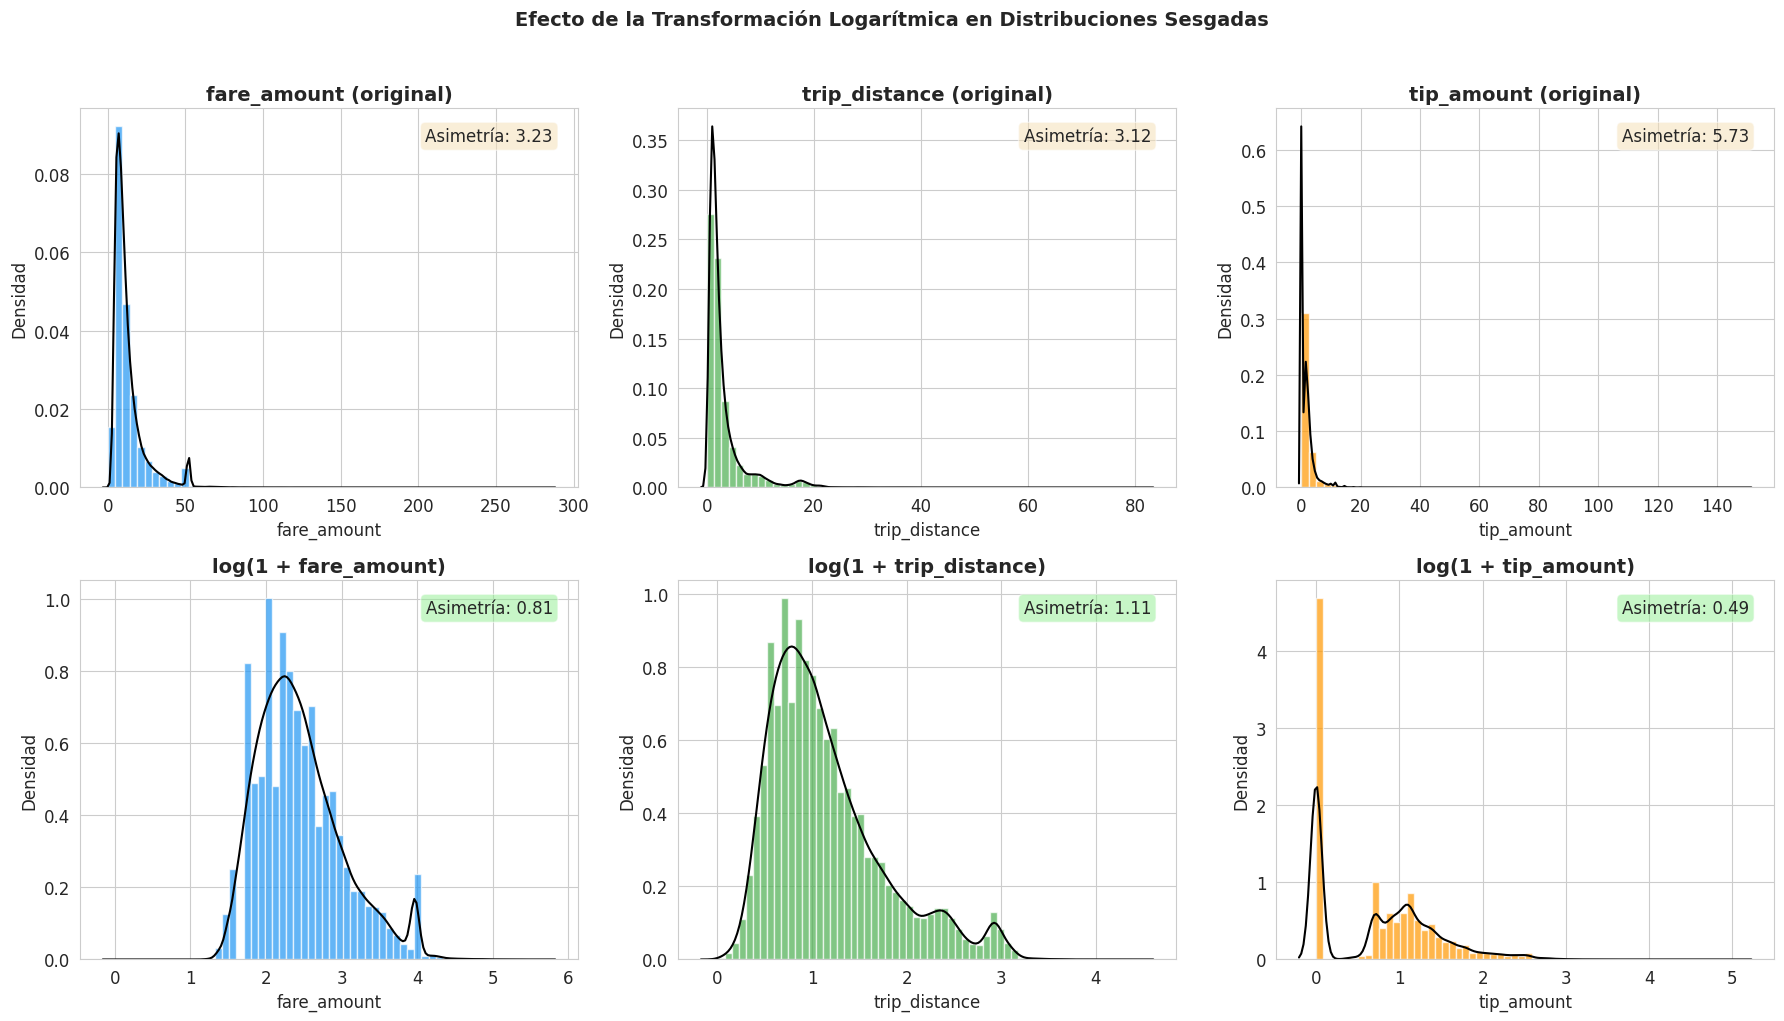


📌 Conclusión:
La transformación log reduce significativamente la asimetría,
acercando las distribuciones a una forma más simétrica (gaussiana).
Esto será útil en fases posteriores cuando apliquemos modelos estadísticos.


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cols = ['fare_amount', 'trip_distance', 'tip_amount']
colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, (col, color) in enumerate(zip(cols, colors)):
    # Fila superior: distribución original
    axes[0, i].hist(df[col], bins=60, color=color, alpha=0.7, edgecolor='white', density=True)
    sns.kdeplot(data=df[col], ax=axes[0, i], color='black', linewidth=1.5)
    axes[0, i].set_title(f'{col} (original)', fontweight='bold')
    axes[0, i].set_ylabel('Densidad')
    skew_orig = df[col].skew()
    axes[0, i].text(0.95, 0.95, f'Asimetría: {skew_orig:.2f}', 
                    transform=axes[0, i].transAxes, ha='right', va='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Fila inferior: distribución log-transformada
    log_data = np.log1p(df[col].clip(lower=0))  # clip para evitar log de negativos
    axes[1, i].hist(log_data, bins=60, color=color, alpha=0.7, edgecolor='white', density=True)
    sns.kdeplot(data=log_data, ax=axes[1, i], color='black', linewidth=1.5)
    axes[1, i].set_title(f'log(1 + {col})', fontweight='bold')
    axes[1, i].set_ylabel('Densidad')
    skew_log = log_data.skew()
    axes[1, i].text(0.95, 0.95, f'Asimetría: {skew_log:.2f}',
                    transform=axes[1, i].transAxes, ha='right', va='top',
                    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.suptitle('Efecto de la Transformación Logarítmica en Distribuciones Sesgadas',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n📌 Conclusión:")
print("La transformación log reduce significativamente la asimetría,")
print("acercando las distribuciones a una forma más simétrica (gaussiana).")
print("Esto será útil en fases posteriores cuando apliquemos modelos estadísticos.")

## Conclusiones del Analisis Univariado

1. **Tarifas:** La distribucion de tarifas esta fuertemente sesgada a la derecha. La mediana (~$10-12) es mas representativa que la media del viaje "tipico".

2. **Distancias:** La mayoria de los viajes son cortos (< 5 millas), consistente con desplazamientos urbanos dentro de Manhattan.

3. **Propinas:** Distribucion bimodal - un pico en $0 (pagos en efectivo no registran propina) y otro alrededor del 15-20% para tarjeta de credito.

4. **Outliers:** El metodo IQR detecta mas outliers que el z-score. Para datos con sesgo, IQR es mas apropiado.

5. **Zonas:** Las zonas TLC permiten comparar tarifas entre Manhattan, Brooklyn, aeropuertos (JFK, LaGuardia) y otras areas. Los viajes desde aeropuertos tienden a tener tarifas mas altas (tarifas planas).

6. **Transformaciones:** La transformacion logaritmica reduce efectivamente la asimetria y sera util para modelado posterior.

### Proximos pasos
- Notebook 02: Analisis de patrones temporales
- Notebook 03: Analisis de pagos y propinas